# KVASIR v2 Balanced Benchmark (Performance-Based LR)

This notebook benchmarks **EfficientNetB3**, **InceptionV3**, and **ResNet50** on the **KVASIR v2 balanced dataset** using a **performance-based learning rate strategy** (`ReduceLROnPlateau` monitoring `val_accuracy`).

Designed to run on Kaggle GPU.

In [1]:
# Basic imports
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB3, InceptionV3, ResNet50
from tensorflow.keras.applications import efficientnet, inception_v3, resnet50
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_HEAD = 12
EPOCHS_FINETUNE = 15
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

print('TensorFlow version:', tf.__version__)

2026-03-27 06:34:49.749068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774593289.959410      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774593290.025404      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774593290.524411      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774593290.524464      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774593290.524467      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
# Use the exact KVASIR dataset path provided by user (Kaggle input)

data_root = '/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset'



if not os.path.isdir(data_root):

    raise FileNotFoundError(

        f'Dataset path not found: {data_root}. Please verify the Kaggle dataset attachment path.'

    )



class_names = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

num_classes = len(class_names)



print('Using dataset root:', data_root)

print('Number of classes:', num_classes)

print('Classes:', class_names)

Using dataset root: /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset
Number of classes: 8
Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


In [3]:
# Build image path/label arrays and split into train/val/test
def get_image_paths_and_labels(folder_path, class_names):
    paths, labels = [], []
    class_to_idx = {cls: i for i, cls in enumerate(class_names)}

    for cls in class_names:
        cls_path = os.path.join(folder_path, cls)
        for img_file in os.listdir(cls_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_path, img_file))
                labels.append(class_to_idx[cls])

    return np.array(paths), np.array(labels)

def split_dataset(paths, labels, seed=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        paths, labels, test_size=0.30, random_state=seed, stratify=labels
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

paths, labels = get_image_paths_and_labels(data_root, class_names)
tr_paths, val_paths, te_paths, ytr, yval, yte = split_dataset(paths, labels, seed=SEED)

print(f'Total: {len(paths)}')
print(f'Train: {len(tr_paths)} | Val: {len(val_paths)} | Test: {len(te_paths)}')

Total: 4000
Train: 2800 | Val: 600 | Test: 600


In [6]:
# Model-specific preprocessing + tf.data pipeline
PREPROCESS_FUNCS = {
    'EfficientNetB3': efficientnet.preprocess_input,
    'InceptionV3': inception_v3.preprocess_input,
    'ResNet50': resnet50.preprocess_input,
}

def create_parse_function(model_name):
    preprocess_fn = PREPROCESS_FUNCS[model_name]

    def parse_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_fn(img)
        label = tf.one_hot(label, num_classes)
        return img, label

    return parse_image

def create_augment_function():
    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.9, 1.1)
        image = tf.image.random_saturation(image, 0.9, 1.1)
        return image, label

    return augment

def create_dataset(paths, labels, model_name, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(create_parse_function(model_name), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(create_augment_function(), num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [7]:
# Model builder (same 3 backbones + custom head style from dl-v5(2))
def build_model(model_name, num_classes, input_shape=(224, 224, 3), trainable_layers='top'):
    if model_name == 'EfficientNetB3':
        base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'InceptionV3':
        base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f'Unknown model: {model_name}')

    if trainable_layers == 'top':
        base.trainable = False
    elif trainable_layers == 'partial':
        base.trainable = True
        n_layers = len(base.layers)
        freeze_until = int(n_layers * 0.7)
        for layer in base.layers[:freeze_until]:
            layer.trainable = False
    else:
        base.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=output)
    return model

In [9]:
# Performance-based LR callbacks + two-stage training
def get_performance_callbacks(model_name, stage_tag):
    ckpt_path = f'/kaggle/working/best_{model_name}_{stage_tag}_performance.keras'
    callbacks = [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(
            monitor='val_accuracy', mode='max', factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
    ]
    return callbacks

def train_two_stage_performance_lr(model_name, tr_paths, val_paths, te_paths, ytr, yval, yte):
    print(f'\n===== Training {model_name} with performance-based LR =====')

    train_ds = create_dataset(tr_paths, ytr, model_name, shuffle=True, augment=True)
    val_ds = create_dataset(val_paths, yval, model_name, shuffle=False, augment=False)
    test_ds = create_dataset(te_paths, yte, model_name, shuffle=False, augment=False)

    # Stage 1
    model = build_model(model_name, num_classes, trainable_layers='top')
    model.compile(optimizer=Adam(INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

    h1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        callbacks=get_performance_callbacks(model_name, 'stage1'),
        verbose=1
    )

    # Stage 2
    model_ft = build_model(model_name, num_classes, trainable_layers='partial')
    model_ft.set_weights(model.get_weights())
    model_ft.compile(optimizer=Adam(FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

    h2 = model_ft.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        callbacks=get_performance_callbacks(model_name, 'finetune'),
        verbose=1
    )

    y_pred = np.argmax(model_ft.predict(test_ds), axis=1)
    y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    results = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'y_true': y_true,
        'y_pred': y_pred,
    }

    history = {
        'loss': h1.history['loss'] + h2.history['loss'],
        'val_loss': h1.history['val_loss'] + h2.history['val_loss'],
        'accuracy': h1.history['accuracy'] + h2.history['accuracy'],
        'val_accuracy': h1.history['val_accuracy'] + h2.history['val_accuracy'],
    }

    return model_ft, history, results

In [10]:
# Train all 3 models
all_histories = {}
all_results = {}
trained_models = {}

model_list = ['EfficientNetB3', 'InceptionV3', 'ResNet50']
for model_name in model_list:
    model, history, results = train_two_stage_performance_lr(
        model_name, tr_paths, val_paths, te_paths, ytr, yval, yte
    )
    key = f'{model_name}_KVASIRv2Balanced_performance'
    trained_models[key] = model
    all_histories[key] = history
    all_results[key] = results

print('\nAll 3 performance-based runs completed.')


===== Training EfficientNetB3 with performance-based LR =====


I0000 00:00:1774593360.133910      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774593360.139748      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12


I0000 00:00:1774593383.835861     125 service.cc:152] XLA service 0x7b4dac006510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774593383.835947     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774593383.835957     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774593388.312748     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-27 06:36:39.467673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:36:39.616653: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:36:39.991242: E external/local_xl

87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5986 - loss: 1.2271

2026-03-27 06:37:27.434897: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:37:27.578863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:37:27.922454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:37:28.071137: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:37:28.929474: E external/local_xla/xla/stream_

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.6000 - loss: 1.2230

2026-03-27 06:38:04.925749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:38:05.071302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:38:05.432399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:38:05.581184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 06:38:05.728861: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.83000, saving model to /kaggle/working/best_EfficientNetB3_stage1_performance.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 128s 891ms/step - accuracy: 0.6014 - loss: 1.2191 - val_accuracy: 0.8300 - val_loss: 0.5741 - learning_rate: 0.0010
Epoch 2/12
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8250 - loss: 0.5853
Epoch 2: val_accuracy improved from 0.83000 to 0.83167, saving model to /kaggle/working/best_EfficientNetB3_stage1_performance.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.8252 - loss: 0.5851 - val_accuracy: 0.8317 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 3/12
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8524 - loss: 0.4994
Epoch 3: val_accuracy improved from 0.83167 to 0.85333, saving model to /kaggle/working/best_EfficientNetB3_stage1_performance.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 14s 161ms/step - accuracy: 0.8525 - loss: 0.4996 - val_accuracy: 0.8533 - val_loss: 0.4925 - learning_rate: 0.0010
Epoc

In [11]:
# Benchmark table
print('\n' + '='*95)
print('KVASIR v2 BALANCED BENCHMARK (PERFORMANCE-BASED LR)')
print('='*95)
print(f'{"Run":<55} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-'*95)

for name, metrics in sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f'{name:<55} {metrics["accuracy"]:>10.4f} {metrics["precision"]:>10.4f} {metrics["recall"]:>10.4f} {metrics["f1"]:>10.4f}')

best_run = max(all_results.items(), key=lambda x: x[1]['f1'])
print('\nBest model:', best_run[0])
print('Best F1-score:', f'{best_run[1]["f1"]:.4f}')


KVASIR v2 BALANCED BENCHMARK (PERFORMANCE-BASED LR)
Run                                                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------------------------------------
EfficientNetB3_KVASIRv2Balanced_performance                 0.8833     0.8838     0.8833     0.8828
ResNet50_KVASIRv2Balanced_performance                       0.8817     0.8856     0.8817     0.8809
InceptionV3_KVASIRv2Balanced_performance                    0.8167     0.8229     0.8167     0.8165

Best model: EfficientNetB3_KVASIRv2Balanced_performance
Best F1-score: 0.8828


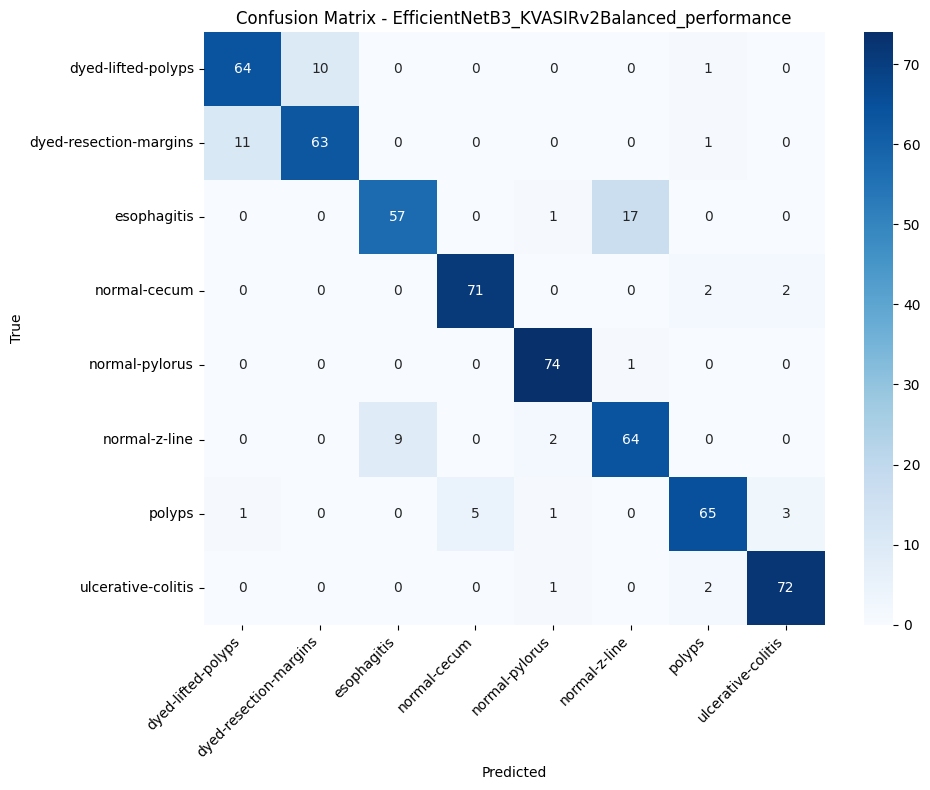

In [12]:
# Confusion matrix for best run
best_name = best_run[0]
best_res = best_run[1]
cm = confusion_matrix(best_res['y_true'], best_res['y_pred'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/kvasir_v2_balanced_best_confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# Save summary
summary = {
    'dataset': 'KVASIR v2 (Balanced)',
    'strategy': 'performance-based LR (ReduceLROnPlateau on val_accuracy)',
    'best_model': best_run[0],
    'results': {
        k: {
            'accuracy': float(v['accuracy']),
            'precision': float(v['precision']),
            'recall': float(v['recall']),
            'f1': float(v['f1'])
        }
        for k, v in all_results.items()
    }
}

out_path = '/kaggle/working/kvasir_v2_balanced_performance_benchmark_summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved benchmark summary to:', out_path)

Saved benchmark summary to: /kaggle/working/kvasir_v2_balanced_performance_benchmark_summary.json
